<a href="https://colab.research.google.com/github/m2nwo079/global-challenger-2026/blob/main/01_module_a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, sqlite3
import pandas as pd
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/globalchallenger'
WORK = '/content/work'
DB   = f'{WORK}/data/db/criteo.db'

os.makedirs(f'{WORK}/data/db', exist_ok=True)
for p in [f'{BASE}/output', f'{BASE}/figures']:
    os.makedirs(p, exist_ok=True)

if not os.path.exists(DB):
    print('Copying DB from Drive...')
    shutil.copy(f'{BASE}/data/db/criteo.db', DB)

con = sqlite3.connect(DB)
con.execute('PRAGMA cache_size = -800000')
con.execute('PRAGMA temp_store = MEMORY')

plt.rcParams['savefig.dpi']   = 300
plt.rcParams['savefig.bbox']  = 'tight'
plt.rcParams['axes.unicode_minus'] = False

print(pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'", con))

Mounted at /content/drive
Copying DB from Drive...
                 name
0         attribution
1  attribution_sample


In [6]:
%%time
q = """
WITH ordered AS (
  SELECT click,
         ROW_NUMBER() OVER (
           PARTITION BY uid, campaign
           ORDER BY timestamp, rowid
         ) AS k
  FROM attribution_sample
)
SELECT k,
       COUNT(*)                    AS impressions,
       SUM(click)                  AS clicks,
       1.0 * SUM(click) / COUNT(*) AS ctr
FROM ordered
GROUP BY k
ORDER BY k
"""
a = pd.read_sql_query(q, con)

print(a.head(20).to_string(index=False, float_format='%.4f'))
print(f'\nk max       : {a.k.max():,}')
print(f'impressions : {a.impressions.sum():,}   (expected 822,703)')
print(f'clicks      : {a.clicks.sum():,}')

 k  impressions  clicks    ctr
 1       390820  131293 0.3359
 2       145693   49423 0.3392
 3        78621   27604 0.3511
 4        49349   18201 0.3688
 5        33808   12843 0.3799
 6        24351    9560 0.3926
 7        18177    7326 0.4030
 8        13960    5793 0.4150
 9        10803    4661 0.4315
10         8590    3675 0.4278
11         6907    3047 0.4411
12         5722    2600 0.4544
13         4774    2242 0.4696
14         3987    1932 0.4846
15         3347    1617 0.4831
16         2833    1397 0.4931
17         2415    1220 0.5052
18         2076    1085 0.5226
19         1792     972 0.5424
20         1550     845 0.5452

k max       : 152
impressions : 822,703   (expected 822,703)
clicks      : 295,678
CPU times: user 6.17 s, sys: 0 ns, total: 6.17 s
Wall time: 6.76 s


threshold   k_max   impression coverage
       50      54   99.881%
      100      46   99.815%
      500      29   99.328%
    1,000      23   98.831%
    5,000      12   95.636%


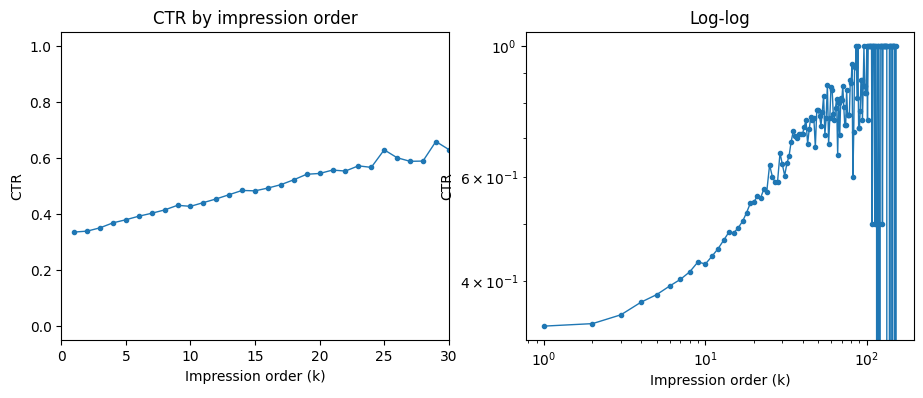

In [7]:
a['cum_share'] = a.impressions.cumsum() / a.impressions.sum()

print('threshold   k_max   impression coverage')
for thr in [50, 100, 500, 1000, 5000]:
    sub = a[a.impressions >= thr]
    if len(sub) == 0:
        continue
    kmax = sub.k.max()
    cov  = a.loc[a.k <= kmax, 'impressions'].sum() / a.impressions.sum()
    print(f'{thr:>9,}   {kmax:>5}   {cov:.3%}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(a.k, a.ctr, marker='o', ms=3, lw=1)
ax[0].set(xlabel='Impression order (k)', ylabel='CTR',
          title='CTR by impression order', xlim=(0, 30))
ax[1].loglog(a.k, a.ctr, marker='o', ms=3, lw=1)
ax[1].set(xlabel='Impression order (k)', ylabel='CTR',
          title='Log-log')
plt.show()

In [8]:
q = """
WITH seq AS (
  SELECT uid, campaign, COUNT(*) AS n, SUM(click) AS c
  FROM attribution_sample
  GROUP BY uid, campaign
)
SELECT n AS seq_len, COUNT(*) AS pairs,
       1.0 * SUM(c) / SUM(n) AS ctr
FROM seq
GROUP BY n
ORDER BY n
LIMIT 20
"""
print(pd.read_sql_query(q, con).to_string(index=False, float_format='%.4f'))

 seq_len  pairs    ctr
       1 245127 0.2721
       2  67072 0.3290
       3  29272 0.3592
       4  15541 0.3794
       5   9457 0.3900
       6   6174 0.4028
       7   4217 0.4073
       8   3157 0.4041
       9   2213 0.4267
      10   1683 0.4241
      11   1185 0.4204
      12    948 0.4380
      13    787 0.4471
      14    640 0.4441
      15    514 0.4533
      16    418 0.4472
      17    339 0.4685
      18    284 0.4644
      19    242 0.4878
      20    215 0.4900


In [9]:
%%time
def cohort_ctr(min_n, table='attribution_sample'):
    q = f"""
    WITH ordered AS (
      SELECT click,
             ROW_NUMBER() OVER (
               PARTITION BY uid, campaign ORDER BY timestamp, rowid) AS k,
             COUNT(*) OVER (PARTITION BY uid, campaign) AS n
      FROM {table}
    )
    SELECT k,
           COUNT(*)                    AS impressions,
           SUM(click)                  AS clicks,
           1.0 * SUM(click) / COUNT(*) AS ctr
    FROM ordered
    WHERE n >= {min_n} AND k <= {min_n}
    GROUP BY k
    ORDER BY k
    """
    d = pd.read_sql_query(q, con)
    d['cohort'] = min_n
    return d

cohorts = {K: cohort_ctr(K) for K in [5, 10, 20]}

for K, d in cohorts.items():
    print(f'--- cohort n >= {K} ---')
    print(d[['k', 'impressions', 'clicks', 'ctr']]
          .to_string(index=False, float_format='%.4f'))
    print()

--- cohort n >= 5 ---
 k  impressions  clicks    ctr
 1        33808   17747 0.5249
 2        33808   15211 0.4499
 3        33808   14133 0.4180
 4        33808   13471 0.3985
 5        33808   12843 0.3799

--- cohort n >= 10 ---
 k  impressions  clicks    ctr
 1         8590    4700 0.5471
 2         8590    4267 0.4967
 3         8590    4165 0.4849
 4         8590    4060 0.4726
 5         8590    3964 0.4615
 6         8590    3917 0.4560
 7         8590    3900 0.4540
 8         8590    3837 0.4467
 9         8590    3844 0.4475
10         8590    3675 0.4278

--- cohort n >= 20 ---
 k  impressions  clicks    ctr
 1         1550     908 0.5858
 2         1550     865 0.5581
 3         1550     859 0.5542
 4         1550     882 0.5690
 5         1550     846 0.5458
 6         1550     847 0.5465
 7         1550     907 0.5852
 8         1550     891 0.5748
 9         1550     877 0.5658
10         1550     864 0.5574
11         1550     850 0.5484
12         1550     850 0.5484


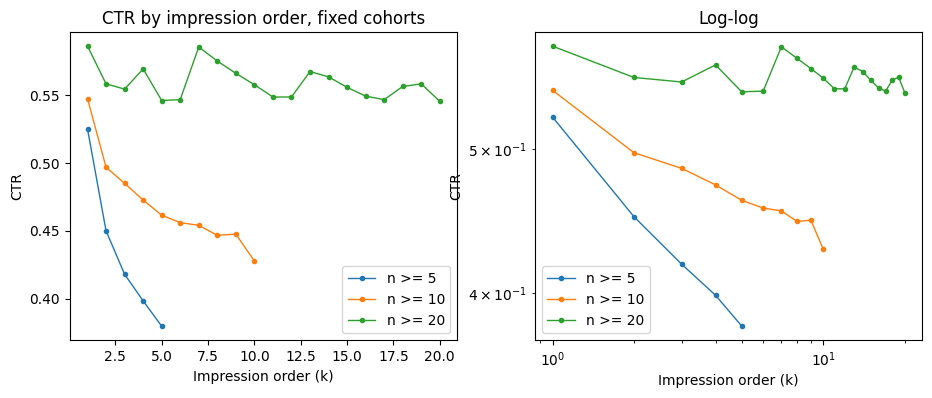

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for K, d in cohorts.items():
    ax[0].plot(d.k, d.ctr, marker='o', ms=3, lw=1, label=f'n >= {K}')
    ax[1].loglog(d.k, d.ctr, marker='o', ms=3, lw=1, label=f'n >= {K}')
ax[0].set(xlabel='Impression order (k)', ylabel='CTR',
          title='CTR by impression order, fixed cohorts')
ax[1].set(xlabel='Impression order (k)', ylabel='CTR', title='Log-log')
for x in ax:
    x.legend()
plt.show()

In [11]:
%%time
con.executescript("""
DROP TABLE IF EXISTS order_agg_sample;
CREATE TABLE order_agg_sample AS
WITH ordered AS (
  SELECT click,
         ROW_NUMBER() OVER (
           PARTITION BY uid, campaign ORDER BY timestamp, rowid) AS k,
         COUNT(*)     OVER (PARTITION BY uid, campaign)          AS n
  FROM attribution_sample
)
SELECT n, k, COUNT(*) AS impressions, SUM(click) AS clicks
FROM ordered GROUP BY n, k;
""")
con.commit()

def cohort_from_agg(K, table='order_agg_sample', exact=False):
    cond = f'n = {K}' if exact else f'n >= {K}'
    d = pd.read_sql_query(f"""
        SELECT k, SUM(impressions) AS impressions, SUM(clicks) AS clicks
        FROM {table} WHERE {cond} AND k <= {K}
        GROUP BY k ORDER BY k
    """, con)
    d['ctr'] = d.clicks / d.impressions
    return d

chk = cohort_from_agg(10)
print(chk.to_string(index=False, float_format='%.4f'))
print('\nexpected: impressions 8590 for every k, ctr 0.5471 -> 0.4278')

 k  impressions  clicks    ctr
 1         8590    4700 0.5471
 2         8590    4267 0.4967
 3         8590    4165 0.4849
 4         8590    4060 0.4726
 5         8590    3964 0.4615
 6         8590    3917 0.4560
 7         8590    3900 0.4540
 8         8590    3837 0.4467
 9         8590    3844 0.4475
10         8590    3675 0.4278

expected: impressions 8590 for every k, ctr 0.5471 -> 0.4278
CPU times: user 7.58 s, sys: 0 ns, total: 7.58 s
Wall time: 7.65 s


In [12]:
import numpy as np
import statsmodels.api as sm

def fit_alpha(d, min_impressions=2000):
    d = d[(d.impressions >= min_impressions) & (d.clicks > 0)].copy()
    if len(d) < 3:
        return None
    y = np.log(d.ctr.values)
    X = sm.add_constant(np.log(d.k.values))
    w = d.impressions.values * d.ctr.values / (1 - d.ctr.values)
    r = sm.WLS(y, X, weights=w).fit()
    lo, hi = r.conf_int()[1]
    return {'alpha': -r.params[1], 'ci_low': -hi, 'ci_high': -lo,
            'r2': r.rsquared, 'k_max': int(d.k.max()),
            'imp_per_k': int(d.impressions.iloc[0])}

rows = []
for K in [5, 10, 20]:
    for exact in [False, True]:
        f = fit_alpha(cohort_from_agg(K, exact=exact))
        if f:
            f.update(cohort=K, definition='n = K' if exact else 'n >= K')
            rows.append(f)

fit_sample = pd.DataFrame(rows)[
    ['cohort', 'definition', 'imp_per_k', 'k_max', 'alpha',
     'ci_low', 'ci_high', 'r2']]
print(fit_sample.to_string(index=False, float_format='%.4f'))

 cohort definition  imp_per_k  k_max  alpha  ci_low  ci_high     r2
      5     n >= K      33808      5 0.1999  0.1803   0.2196 0.9971
      5      n = K       9457      5 0.2917  0.2745   0.3090 0.9990
     10     n >= K       8590     10 0.0942  0.0815   0.1069 0.9733


In [13]:
%%time
con.executescript("""
DROP TABLE IF EXISTS order_agg;
CREATE TABLE order_agg AS
WITH ordered AS (
  SELECT click,
         ROW_NUMBER() OVER (
           PARTITION BY uid, campaign ORDER BY timestamp, rowid) AS k,
         COUNT(*)     OVER (PARTITION BY uid, campaign)          AS n
  FROM attribution
)
SELECT n, k, COUNT(*) AS impressions, SUM(click) AS clicks
FROM ordered GROUP BY n, k;
""")
con.commit()

print(pd.read_sql_query("""
SELECT SUM(impressions) AS impressions, SUM(clicks) AS clicks,
       MAX(n) AS n_max, MAX(k) AS k_max, COUNT(*) AS agg_rows
FROM order_agg
""", con).T)

                    0
impressions  16468027
clicks        5947563
n_max             376
k_max             376
agg_rows        18452
CPU times: user 3min 47s, sys: 2.34 s, total: 3min 49s
Wall time: 3min 55s


In [14]:
def cohort(K, exact=True, table='order_agg'):
    cond = f'n = {K}' if exact else f'n >= {K}'
    d = pd.read_sql_query(f"""
        SELECT k, SUM(impressions) AS impressions, SUM(clicks) AS clicks
        FROM {table} WHERE {cond} AND k <= {K}
        GROUP BY k ORDER BY k
    """, con)
    d['ctr'] = d.clicks / d.impressions
    return d

def fit_alpha(d, min_impressions=5000):
    d = d[(d.impressions >= min_impressions) & (d.clicks > 0)]
    if len(d) < 3:
        return None
    y = np.log(d.ctr.values)
    X = sm.add_constant(np.log(d.k.values))
    w = d.impressions.values * d.ctr.values / (1 - d.ctr.values)
    r = sm.WLS(y, X, weights=w).fit()
    lo, hi = r.conf_int()[1]
    return {'alpha': -r.params[1], 'ci_low': -hi, 'ci_high': -lo,
            'r2': r.rsquared, 'ctr_first': d.ctr.iloc[0],
            'ctr_last': d.ctr.iloc[-1], 'pairs': int(d.impressions.iloc[0])}

rows = []
for K in [3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, 40, 50]:
    for exact in [True, False]:
        f = fit_alpha(cohort(K, exact))
        if f:
            f.update(n=K, definition='n = K' if exact else 'n >= K')
            rows.append(f)

fit = pd.DataFrame(rows)[['definition', 'n', 'pairs', 'ctr_first',
                          'ctr_last', 'alpha', 'ci_low', 'ci_high', 'r2']]
print(fit.to_string(index=False, float_format='%.4f'))

definition  n   pairs  ctr_first  ctr_last   alpha  ci_low  ci_high     r2
     n = K  3  582617     0.4582    0.2894  0.4230  0.2530   0.5931 0.9990
    n >= K  3 1569215     0.4938    0.3536  0.3061  0.2250   0.3871 0.9996
     n = K  4  312637     0.4950    0.3063  0.3528  0.3159   0.3898 0.9988
    n >= K  4  986598     0.5148    0.3684  0.2442  0.2233   0.2651 0.9992
     n = K  5  188187     0.5101    0.3200  0.2936  0.2831   0.3041 0.9996
    n >= K  5  673961     0.5240    0.3808  0.1990  0.1901   0.2079 0.9994
     n = K  6  122763     0.5201    0.3307  0.2534  0.2444   0.2624 0.9993
    n >= K  6  485774     0.5294    0.3933  0.1657  0.1585   0.1729 0.9990
     n = K  8   60604     0.5258    0.3487  0.1915  0.1797   0.2033 0.9962
    n >= K  8  278589     0.5356    0.4176  0.1171  0.1109   0.1233 0.9972
     n = K 10   33017     0.5232    0.3648  0.1473  0.1346   0.1601 0.9888
    n >= K 10  173977     0.5412    0.4388  0.0854  0.0794   0.0914 0.9926
     n = K 12   19991    

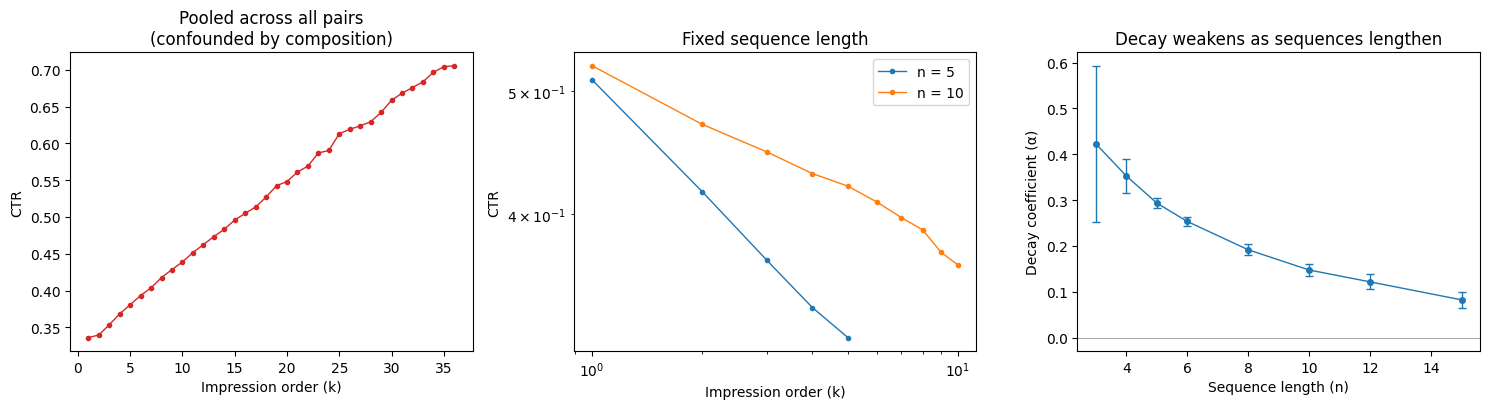

In [15]:
naive = pd.read_sql_query("""
    SELECT k, SUM(impressions) AS impressions, SUM(clicks) AS clicks
    FROM order_agg GROUP BY k ORDER BY k
""", con)
naive['ctr'] = naive.clicks / naive.impressions

ex = fit[fit.definition == 'n = K']

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

m = naive.impressions >= 5000
ax[0].plot(naive.k[m], naive.ctr[m], marker='o', ms=3, lw=1, color='tab:red')
ax[0].set(xlabel='Impression order (k)', ylabel='CTR',
          title='Pooled across all pairs\n(confounded by composition)')

for K in [5, 10, 20, 30]:
    d = cohort(K)
    if d.impressions.iloc[0] >= 5000:
        ax[1].plot(d.k, d.ctr, marker='o', ms=3, lw=1, label=f'n = {K}')
ax[1].set(xlabel='Impression order (k)', ylabel='CTR',
          title='Fixed sequence length', xscale='log', yscale='log')
ax[1].legend()

ax[2].errorbar(ex.n, ex.alpha,
               yerr=[ex.alpha - ex.ci_low, ex.ci_high - ex.alpha],
               marker='o', ms=4, lw=1, capsize=3)
ax[2].axhline(0, color='gray', lw=0.5)
ax[2].set(xlabel='Sequence length (n)', ylabel='Decay coefficient (α)',
          title='Decay weakens as sequences lengthen')

plt.tight_layout()
plt.savefig(f'{BASE}/figures/module_a_decay.png')
plt.show()

In [16]:
import json

out = {
    'baselines': {
        'impressions': 16468027, 'clicks': 5947563,
        'users': 6142256, 'campaigns': 675,
        'pooled_ctr': 5947563 / 16468027,
        'n_max': 376,
    },
    'pooled_by_order': naive[naive.impressions >= 5000][
        ['k', 'impressions', 'clicks', 'ctr']].to_dict('records'),
    'cohort_fits': fit.to_dict('records'),
    'cohort_curves': {
        f'n={K}': cohort(K)[['k', 'impressions', 'clicks', 'ctr']]
                    .to_dict('records')
        for K in [5, 10, 20, 30]
    },
}

with open(f'{BASE}/output/module_a.json', 'w') as f:
    json.dump(out, f, indent=2)

print('saved:', f'{BASE}/output/module_a.json')
print('size :', os.path.getsize(f'{BASE}/output/module_a.json'), 'bytes')

saved: /content/drive/MyDrive/globalchallenger/output/module_a.json
size : 17823 bytes


In [17]:
print(pd.read_sql_query("""
SELECT n, SUM(impressions) AS impressions, SUM(clicks) AS clicks,
       1.0 * SUM(clicks) / SUM(impressions) AS ctr
FROM order_agg WHERE n <= 6 GROUP BY n ORDER BY n
""", con).to_string(index=False, float_format='%.4f'))

 n  impressions  clicks    ctr
 1      4900078 1332716 0.2720
 2      2688216  885179 0.3293
 3      1747851  632409 0.3618
 4      1250548  475152 0.3800
 5       940935  367461 0.3905
 6       736578  293572 0.3986


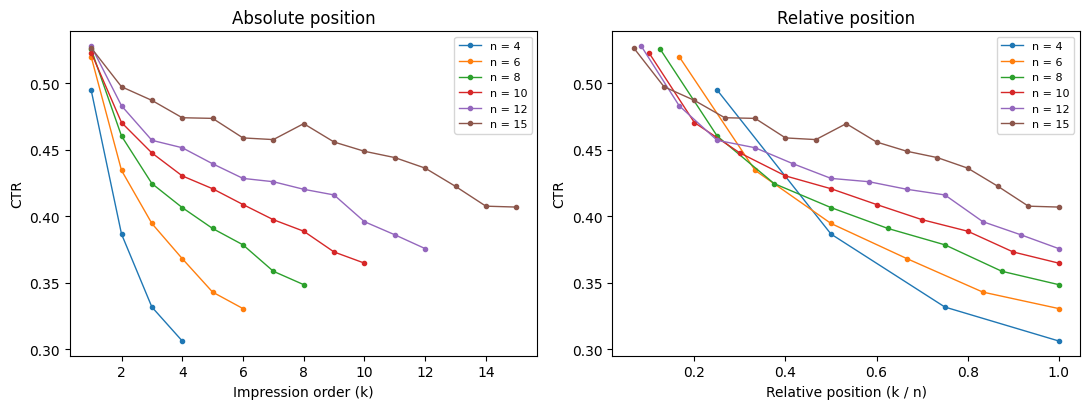

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

for K in [4, 6, 8, 10, 12, 15]:
    d = cohort(K)
    if d.impressions.iloc[0] < 5000:
        continue
    ax[0].plot(d.k, d.ctr, marker='o', ms=3, lw=1, label=f'n = {K}')
    ax[1].plot(d.k / K, d.ctr, marker='o', ms=3, lw=1, label=f'n = {K}')

ax[0].set(xlabel='Impression order (k)', ylabel='CTR',
          title='Absolute position')
ax[1].set(xlabel='Relative position (k / n)', ylabel='CTR',
          title='Relative position')
for x in ax:
    x.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{BASE}/figures/module_a_position.png')
plt.show()

In [20]:
def cohort_trim(K, drop_last, table='order_agg'):
    d = pd.read_sql_query(f"""
        SELECT k, impressions, clicks FROM {table}
        WHERE n = {K} AND k <= {K - drop_last} ORDER BY k
    """, con)
    d['ctr'] = d.clicks / d.impressions
    return d

rows = []
for K in [6, 8, 10, 12, 15]:
    for dl in [0, 1, 2]:
        d = cohort_trim(K, dl)
        f = fit_alpha(d)
        if f:
            f.update(n=K, dropped=dl)
            rows.append(f)

trim = pd.DataFrame(rows)[['n', 'dropped', 'ctr_first', 'ctr_last',
                           'alpha', 'ci_low', 'ci_high', 'r2']]
print(trim.to_string(index=False, float_format='%.4f'))

 n  dropped  ctr_first  ctr_last  alpha  ci_low  ci_high     r2
 6        0     0.5201    0.3307 0.2534  0.2444   0.2624 0.9993
 6        1     0.5201    0.3431 0.2540  0.2404   0.2675 0.9992
 6        2     0.5201    0.3682 0.2500  0.2341   0.2660 0.9996
 8        0     0.5258    0.3487 0.1915  0.1797   0.2033 0.9962
 8        1     0.5258    0.3587 0.1884  0.1763   0.2005 0.9969
 8        2     0.5258    0.3786 0.1840  0.1749   0.1931 0.9987
10        0     0.5232    0.3648 0.1473  0.1346   0.1601 0.9888
10        1     0.5232    0.3732 0.1433  0.1321   0.1545 0.9924
10        2     0.5232    0.3889 0.1388  0.1320   0.1456 0.9976
12        0     0.5281    0.3758 0.1214  0.1053   0.1376 0.9655
12        1     0.5281    0.3862 0.1164  0.1024   0.1304 0.9752
12        2     0.5281    0.3960 0.1119  0.1000   0.1238 0.9833
15        0     0.5268    0.4070 0.0821  0.0645   0.0997 0.8867
15        1     0.5268    0.4077 0.0778  0.0611   0.0944 0.8961
15        2     0.5268    0.4226 0.0720 

In [21]:
d = pd.read_sql_query("""
SELECT n, impressions, clicks, 1.0 * clicks / impressions AS ctr_k1
FROM order_agg WHERE k = 1 AND n <= 20 ORDER BY n
""", con)
d['share_of_all_imp'] = None
tot = pd.read_sql_query(
    "SELECT SUM(impressions) s FROM order_agg", con).s[0]
seq = pd.read_sql_query("""
SELECT n, SUM(impressions) AS imp FROM order_agg
WHERE n <= 20 GROUP BY n ORDER BY n
""", con)
d['seq_imp_share'] = (seq.imp / tot).values
print(d.to_string(index=False, float_format='%.4f'))
print(f'\nn <= 2 share of all impressions: '
      f'{seq[seq.n <= 2].imp.sum() / tot:.2%}')

 n  impressions  clicks  ctr_k1 share_of_all_imp  seq_imp_share
 1      4900078 1332716  0.2720             None         0.2976
 2      1344108  519281  0.3863             None         0.1632
 3       582617  266936  0.4582             None         0.1061
 4       312637  154767  0.4950             None         0.0759
 5       188187   95997  0.5101             None         0.0571
 6       122763   63855  0.5201             None         0.0447
 7        84422   44108  0.5225             None         0.0359
 8        60604   31865  0.5258             None         0.0294
 9        44008   23177  0.5267             None         0.0241
10        33017   17276  0.5232             None         0.0200
11        25309   13435  0.5308             None         0.0169
12        19991   10558  0.5281             None         0.0146
13        15692    8270  0.5270             None         0.0124
14        12667    6822  0.5386             None         0.0108
15        10341    5448  0.5268         

In [22]:
q = """
SELECT k,
  SUM(CASE WHEN n =  k THEN impressions ELSE 0 END) AS imp_last,
  SUM(CASE WHEN n =  k THEN clicks      ELSE 0 END) AS clk_last,
  SUM(CASE WHEN n >  k THEN impressions ELSE 0 END) AS imp_cont,
  SUM(CASE WHEN n >  k THEN clicks      ELSE 0 END) AS clk_cont
FROM order_agg WHERE k <= 15 GROUP BY k ORDER BY k
"""
h = pd.read_sql_query(q, con)
h['ctr_terminal']  = h.clk_last / h.imp_last
h['ctr_continues'] = h.clk_cont / h.imp_cont
h['ratio']         = h.ctr_continues / h.ctr_terminal
h['stop_rate']     = h.imp_last / (h.imp_last + h.imp_cont)

print(h[['k', 'imp_last', 'imp_cont', 'ctr_terminal',
         'ctr_continues', 'ratio', 'stop_rate']]
      .to_string(index=False, float_format='%.4f'))

 k  imp_last  imp_cont  ctr_terminal  ctr_continues  ratio  stop_rate
 1   4900078   2913323        0.2720         0.4442 1.6333     0.6271
 2   1344108   1569215        0.2722         0.3973 1.4594     0.4614
 3    582617    986598        0.2894         0.3915 1.3529     0.3713
 4    312637    673961        0.3063         0.3973 1.2971     0.3169
 5    188187    485774        0.3200         0.4043 1.2637     0.2792
 6    122763    363011        0.3307         0.4145 1.2534     0.2527
 7     84422    278589        0.3344         0.4248 1.2703     0.2326
 8     60604    217985        0.3487         0.4368 1.2528     0.2175
 9     44008    173977        0.3553         0.4472 1.2587     0.2019
10     33017    140960        0.3648         0.4561 1.2502     0.1898
11     25309    115651        0.3713         0.4693 1.2641     0.1795
12     19991     95660        0.3758         0.4804 1.2784     0.1729
13     15692     79968        0.3838         0.4909 1.2791     0.1640
14     12667     673

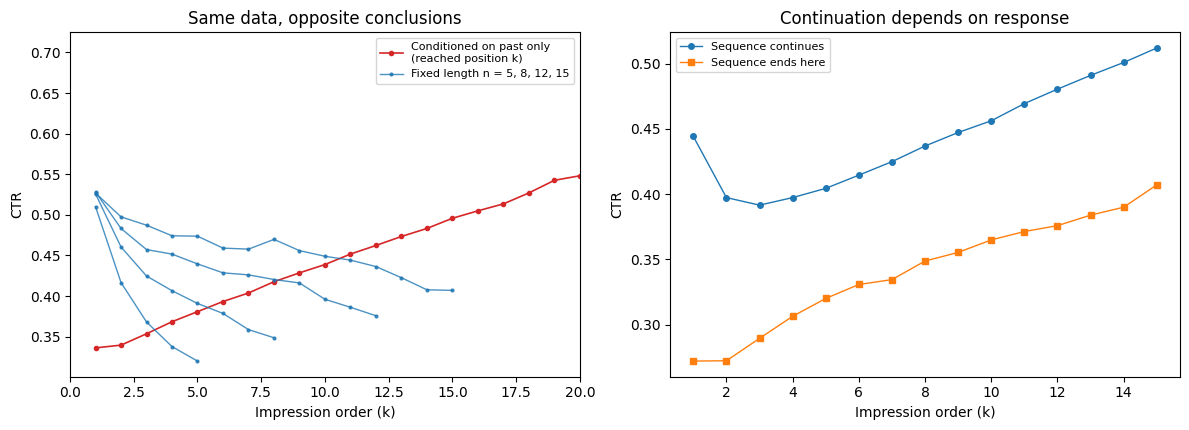

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

m = naive.impressions >= 5000
ax[0].plot(naive.k[m], naive.ctr[m], marker='o', ms=3, lw=1.2,
           color='tab:red', label='Conditioned on past only\n(reached position k)')
for K in [5, 8, 12, 15]:
    c = cohort(K)
    if c.impressions.iloc[0] >= 5000:
        ax[0].plot(c.k, c.ctr, marker='.', ms=4, lw=1, alpha=0.8,
                   label=f'Fixed length n = 5, 8, 12, 15' if K == 5 else None,
                   color='tab:blue')
ax[0].set(xlabel='Impression order (k)', ylabel='CTR', xlim=(0, 20),
          title='Same data, opposite conclusions')
ax[0].legend(fontsize=8)

ax[1].plot(h.k, h.ctr_continues, marker='o', ms=4, lw=1,
           label='Sequence continues')
ax[1].plot(h.k, h.ctr_terminal, marker='s', ms=4, lw=1,
           label='Sequence ends here')
ax[1].set(xlabel='Impression order (k)', ylabel='CTR',
          title='Continuation depends on response')
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{BASE}/figures/module_a_conditioning.png')
plt.show()

In [24]:
import json

out = {
    'baselines': {
        'impressions': 16468027, 'clicks': 5947563,
        'users': 6142256, 'campaigns': 675,
        'pooled_ctr': 5947563 / 16468027, 'n_max': 376,
        'share_n_le_2': 0.4608, 'stop_rate_at_k1': 0.6271,
    },
    'pooled_by_order':  naive[naive.impressions >= 5000][
        ['k','impressions','clicks','ctr']].to_dict('records'),
    'cohort_fits':      fit.to_dict('records'),
    'trim_robustness':  trim.to_dict('records'),
    'first_impression_by_length': d[
        ['n','impressions','clicks','ctr_k1']].to_dict('records'),
    'continuation_hazard': h[
        ['k','imp_last','imp_cont','ctr_terminal',
         'ctr_continues','ratio','stop_rate']].to_dict('records'),
    'cohort_curves': {
        f'n={K}': cohort(K)[['k','impressions','clicks','ctr']]
                    .to_dict('records')
        for K in [3,5,8,10,12,15]
    },
    'notes': [
        'Pooled impression-order CTR rises (0.337 to 0.707); '
        'fixed-length cohorts fall. Both are correct arithmetic.',
        'Trimming the last 1-2 impressions leaves alpha unchanged and '
        'improves R2, so decay is not a sequence-termination artifact.',
        'CTR does not collapse onto relative position k/n.',
        'Sequences that continue have 25-28% higher CTR at the same '
        'position, so total length n is an outcome, not a covariate.',
        'No causal fatigue coefficient is identified from these logs.',
    ],
}

with open(f'{BASE}/output/module_a.json', 'w') as fh:
    json.dump(out, fh, indent=2)

print('saved:', os.path.getsize(f'{BASE}/output/module_a.json'), 'bytes')

saved: 27029 bytes
